# AGBD Implementation Pipeline

Basic pipeline for the application of the trained Nico-Net model from the AGBD paper to new regions by automatically fetching the data from google earth engine.

# Instructions

When required, you'll need to authenticate with your own account to google earth engine and specify your own project.

In [1]:
# Install additonal dependencies required
!pip -q install earthengine-api geemap rasterio rioxarray xarray pyproj tiler lightning matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.0 MB/s eta 0:00:00


In [2]:
# import scripts from github repositories
# nico_net architecture
!wget -O paper_models.py "https://raw.githubusercontent.com/ghjuliasialelli/AGBD/main/Models/models.py"
!wget -O nico_net.py "https://raw.githubusercontent.com/ghjuliasialelli/AGBD/main/Models/nico_net.py"
# various additional functions to import and process the data from gee and write the final agbd map
!wget -O utils.py "https://raw.githubusercontent.com/Frankie91/AGBD_Inference/main/utils.py"

--2026-05-14 08:37:29--  https://raw.githubusercontent.com/ghjuliasialelli/AGBD/main/Models/models.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9582 (9.4K) [text/plain]
Saving to: ‘paper_models.py’

paper_models.py     100%[===================>]   9.36K  --.-KB/s    in 0s      

2026-05-14 08:37:30 (94.2 MB/s) - ‘paper_models.py’ saved [9582/9582]

--2026-05-14 08:37:30--  https://raw.githubusercontent.com/ghjuliasialelli/AGBD/main/Models/nico_net.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9490 (9.3K) [text/plain]
Sa

In [ ]:
# Import nico-net weights
# two specific sets of nico_net weights selected because of their mention here:
# https://github.com/ghjuliasialelli/AGBD/blob/main/Models/inference.sh
!wget -O 18693595-1_best.ckpt "https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2Fpretrained_weights%2Fnico&files=18693595-1_best.ckpt"
!wget -O 18693595-1_cfg.pkl "https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2Fpretrained_weights%2Fnico&files=18693595-1_cfg.pkl"
!wget -O 18693595-3_best.ckpt "https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2Fpretrained_weights%2Fnico&files=18693595-3_best.ckpt"
!wget -O 18693595-3_cfg.pkl "https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2Fpretrained_weights%2Fnico&files=18693595-3_cfg.pkl"


--2026-05-14 08:37:30--  https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2Fpretrained_weights%2Fnico&files=18693595-1_best.ckpt
Resolving libdrive.ethz.ch (libdrive.ethz.ch)... 129.132.71.248
Connecting to libdrive.ethz.ch (libdrive.ethz.ch)|129.132.71.248|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 123556338 (118M) [application/octet-stream]
Saving to: ‘18693595-1_best.ckpt’

18693595-1_best.ckp 100%[===================>] 117.83M  20.8MB/s    in 7.1s    

2026-05-14 08:37:38 (16.7 MB/s) - ‘18693595-1_best.ckpt’ saved [123556338/123556338]

--2026-05-14 08:37:38--  https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2Fpretrained_weights%2Fnico&files=18693595-1_cfg.pkl
Resolving libdrive.ethz.ch (libdrive.ethz.ch)... 129.132.71.248
Connecting to libdrive.ethz.ch (libdrive.ethz.ch)|129.132.71.248|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1017 [application/octet-stream]
Saving to: ‘18693595-1

In [ ]:
# Importing already generated tile for final comparison
!wget -O 34TGL.tif "https://libdrive.ethz.ch/index.php/s/VPio6i5UlXTgir0/download?path=%2Fpredictions&files=34TGL.tif"

In [ ]:
# Import normalization bounds
!wget -O statistics_subset_2019-2020-v4_new.pkl "https://libdrive.ethz.ch/index.php/s/Y9A9b156b8H0KYf/download?path=%2F&files=statistics_subset_2019-2020-v4_new.pkl"

In [ ]:
import numpy as np
import ee
import rasterio
import pickle
from tiler import Tiler, Merger
import torch
import rasterio.enums
import rioxarray as rxr
from pyproj import Transformer
import matplotlib.pyplot as plt

import paper_models as mods
import utils as ut

In [ ]:
# Earth Engine authentication and initialization
# Requires an earth engine account and project
ee.Authenticate()
ee.Initialize(
    project='tanithsoc-489107', # Replace project with your own
    opt_url='https://earthengine-highvolume.googleapis.com'
)

In [ ]:
# Loading normalization values dictionary
# Min-max for every channel can be retrieved from here
with open('statistics_subset_2019-2020-v4_new.pkl', 'rb') as file:
    Norm_Values = pickle.load(file)

# Testing in Northern Greece
S2_tile = "34TGL"
AOIcrs = "EPSG:2100"
# test regions within this tile used so far
# AOI = 24.00551587,40.94915108,24.03336070,40.97226228
AOI = 23.98311359,40.90969646,24.00233295,40.92263750

# slightly enlarge the download area to minimize border effects
# in the final AGBD estimate
incr_fact = 0.01

topY = AOI[3] + incr_fact
bottomY = AOI[1] - incr_fact
rightX = AOI[2] + incr_fact
leftX = AOI[0] - incr_fact

region = ee.Geometry.BBox(leftX, bottomY, rightX, topY)

In [ ]:
# ---------------------------------------------------------------------------#
# Sentinel 2 Processing -----------------------------------------------------#
# ---------------------------------------------------------------------------#

# intervals must be either day before and after (to get a single specific
# product for that tile) or longer. always passed as a list of lists, even for
# a single product.

# Greece
s2_time_ranges = [["2020-08-30", "2020-09-01"],
    ["2020-11-25", "2020-11-27"]]

months_list = [tr[0].split('-')[1] + '_' + tr[0].split('-')[0][2:] for tr in s2_time_ranges]

bands10 = ["B2", "B3", "B4", "B8"]
bands20 = ["B5", "B6", "B7", "B8A", "B11", "B12"]
bands60 = ["B1", "B9"]

for m, tr in enumerate(s2_time_ranges):
    month = months_list[m]
    s2_10m_path = f"S2_10m_{month}.tif"
    # 1. Export 10 m stack as reference grid
    ut.sentinel2_processing(
        band_names=bands10,
        export_scale=10,
        final_tif=s2_10m_path,
        aoi_crs=AOIcrs,
        region=region,
        norm_values=Norm_Values,
        s2_tile=S2_tile,
        s2_time_range=tr,
    )

    # 2. Open the saved 10 m raster as alignment template
    with rxr.open_rasterio(s2_10m_path) as match_10m:
        # 3. Export 20 m and align to 10 m
        ut.sentinel2_processing(
            band_names=bands20,
            export_scale=20,
            final_tif=f"S2_20m_{month}.tif",
            aoi_crs=AOIcrs,
            region=region,
            norm_values=Norm_Values,
            s2_tile=S2_tile,
            s2_time_range=tr,
            match_raster=match_10m
        )

        # 4. Export 60 m and align to 10 m
        ut.sentinel2_processing(
            band_names=bands60,
            export_scale=60,
            final_tif=f"S2_60m_{month}.tif",
            aoi_crs=AOIcrs,
            region=region,
            norm_values=Norm_Values,
            s2_tile=S2_tile,
            s2_time_range=tr,
            match_raster=match_10m
        )

In [ ]:
# ---------------------------------------------------------------------------#
# Lat\Lon Sin\Cos Layers Calculation ----------------------------------------#
# ---------------------------------------------------------------------------#
with rxr.open_rasterio(s2_10m_path) as s2_10m:
    ref_lon = s2_10m.x.values
    ref_lat = s2_10m.y.values

    xx, yy = np.meshgrid(ref_lon, ref_lat)

    transformer = Transformer.from_crs(
        s2_10m.rio.crs,
        "EPSG:4326",
        always_xy=True
    )

    lon, lat = transformer.transform(xx, yy)

lat_cos = (np.cos((np.pi * lat) / 90) + 1) / 2
lat_sin = (np.sin((np.pi * lat) / 90) + 1) / 2
lon_cos = (np.cos((np.pi * lon) / 180) + 1) / 2
lon_sin = (np.sin((np.pi * lon) / 180) + 1) / 2

ut.array_to_raster("LatCos.tif",
                   lat_cos, AOIcrs, ref_lat, ref_lon)

ut.array_to_raster("LatSin.tif",
                   lat_sin, AOIcrs, ref_lat, ref_lon)

ut.array_to_raster("LonCos.tif",
                   lon_cos, AOIcrs, ref_lat, ref_lon)

ut.array_to_raster("LonSin.tif",
                   lon_sin, AOIcrs, ref_lat, ref_lon)

In [ ]:
# ---------------------------------------------------------------------------#
# Alos Dsm Processing -------------------------------------------------------#
# ---------------------------------------------------------------------------#
dataset = ee.ImageCollection("JAXA/ALOS/AW3D30/V4_1").select("DSM")
filtered_collection = dataset.filterBounds(region)

mosaicked_dsm = filtered_collection.mosaic()

with rxr.open_rasterio(s2_10m_path) as s2_10m:
    ut.dsm_processing(
        img=mosaicked_dsm,
        final_tif="ALOS_DSM.tif",
        match_raster=s2_10m,
        aoi_crs=AOIcrs,
        region=region,
        norm_values=Norm_Values
    )

Generating URL ...
Please wait ...
Data downloaded to /tmp/tmpewds6ubp.tif


In [ ]:
# ---------------------------------------------------------------------------#
# Alos Palsar Processing  ---------------------------------------------------#
# ---------------------------------------------------------------------------#

alos_bands = ["HH", "HV"]

palsar_years = [2020]
# in case multi-year median is a better approach, uncomment below and comment above.
# palsar_years = [2018, 2019, 2020]

with rxr.open_rasterio(s2_10m_path) as s2_10m:
    ut.palsar_processing(
        region,
        AOIcrs,
        s2_10m,
        years=palsar_years,
        norm_values=Norm_Values,
        s2_10m_path=s2_10m_path
    )

Generating URL ...
Please wait ...


Data downloaded to /tmp/tmp1d3vxdel.tif


In [ ]:
# ---------------------------------------------------------------------------#
# Copernicus Land cover processing ------------------------------------------#
# ---------------------------------------------------------------------------#

with rxr.open_rasterio(s2_10m_path) as s2_10m:
    ut.landcover_processing(
        region=region,
        match_raster=s2_10m,
        aoi_crs=AOIcrs
    )

Generating URL ...
Please wait ...
Data downloaded to /tmp/tmp64dncdwo.tif
Generating URL ...
Please wait ...
Data downloaded to /tmp/tmpgthhzb2s.tif


In [ ]:
# ---------------------------------------------------------------------------#
# Inference -----------------------------------------------------------------#
# ---------------------------------------------------------------------------#

# Stacked array construction

agb_estimates = []

device = torch.device("cuda")


# loop over s2 images used
for month in months_list:

    # Read grouped S2 rasters
    with rasterio.open(f"S2_10m_{month}.tif") as src:
        s2_10 = src.read()

    with rasterio.open(f"S2_20m_{month}.tif") as src:
        s2_20 = src.read()

    with rasterio.open(f"S2_60m_{month}.tif") as src:
        s2_60 = src.read()

    # Map arrays to actual band names
    s2_dict = {
        "B2":  s2_10[0],
        "B3":  s2_10[1],
        "B4":  s2_10[2],
        "B8":  s2_10[3],
        "B5":  s2_20[0],
        "B6":  s2_20[1],
        "B7":  s2_20[2],
        "B8A": s2_20[3],
        "B11": s2_20[4],
        "B12": s2_20[5],
        "B1":  s2_60[0],
        "B9":  s2_60[1],
    }

    # Desired Sentinel-2 order
    s2_order = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]
    # Build ordered S2 stack

    s2_stack = np.stack([s2_dict[b] for b in s2_order], axis=0)

    raster_files = [
        "LatCos", "LatSin", "LonCos", "LonSin",
        "Palsar_HH", "Palsar_HV",
        "LC_Cos","LC_Sin","LC_Prob", "ALOS_DSM"
    ]

    stacked_layers = []

    for file in raster_files:
        with rasterio.open(file + '.tif') as src:
            data = src.read()
            stacked_layers.append(data)

    stacked_vars = np.concatenate(stacked_layers, axis=0)

    stacked_array = np.concatenate([s2_stack, stacked_vars])

    # model definition and weights loading

    weights_list = [
        '18693595-1_best.ckpt',
        '18693595-3_best.ckpt',
    ]

    for w in weights_list:
        agb_out_name = f"AGB_{month}_{w.split('_')[0]}.tif"
        agb_estimates.append(agb_out_name)

        cfg_path = w.split('_')[0] + '_cfg.pkl'
        # Loading Config Dictionary
        with open(cfg_path, 'rb') as file:
            cfg = pickle.load(file)

        state = torch.load(w, map_location=device)
        state_dict = state['state_dict']
        state_dict = {k.replace('model.model.', 'model.'): v for k, v in state_dict.items()}

        model = mods.Net('nico', in_features=cfg['in_features'],
                         num_outputs = cfg['num_outputs'],
                         channel_dims=cfg['channel_dims'],
                         num_sepconv_blocks=cfg['num_sepconv_blocks'],
                         num_sepconv_filters=cfg['num_sepconv_filters'],
                         patch_size=cfg['patch_size'],
                         max_pool=cfg['max_pool'],
                         long_skip = cfg['long_skip']).to(device)


        model.load_state_dict(state_dict)

        torch.set_float32_matmul_precision('high')
        model = torch.compile(model, backend="inductor", mode="default", dynamic=False)
        model.eval()

        # --------------------------------------------------------------------------#
        # Dense center-pixel inference ---------------------------------------------#
        # --------------------------------------------------------------------------#

        patch_size = 25
        half = patch_size // 2
        batch_size = 1024

        # stacked_array must be (C, H, W)
        C, H, W = stacked_array.shape

        # reflect padding on spatial axes only
        padded = np.pad(
            stacked_array,
            ((0, 0), (half, half), (half, half)),
            mode="reflect"
        )

        Pred_Arr = np.empty((H, W), dtype=np.float32)

        with torch.no_grad():
            for row in range(H):
                patches = []

                for col in range(W):
                    patch = padded[:, row:row + patch_size, col:col + patch_size]
                    patches.append(patch)

                patches = np.stack(patches, axis=0).astype(np.float32)

                for start in range(0, W, batch_size):
                    batch_np = patches[start:start + batch_size]
                    batch_t = torch.from_numpy(batch_np).to(device)

                    out = model(batch_t)


                    center_pred = out[:, 0, half, half]


                    Pred_Arr[row, start:start + len(center_pred)] = center_pred.detach().cpu().numpy()

        Pred_Arr[Pred_Arr < 0] = 0

        # --------------------------------------------------------------------------#
        # Write raster -------------------------------------------------------------#
        # --------------------------------------------------------------------------#

        with rxr.open_rasterio(s2_10m_path) as s2_10m:
            ref_lon = s2_10m.x.values
            ref_lat = s2_10m.y.values

        agb_out_name = f"AGB_{month}_{w.split('_')[0]}.tif"
        agb_estimates.append(agb_out_name)

        ut.array_to_raster(
            agb_out_name,
            Pred_Arr,
            AOIcrs,
            ref_lat,
            ref_lon
        )

        # --------------------------------------------------------------------------#
        # Rescale and clip ---------------------------------------------------------#
        # --------------------------------------------------------------------------#

        with rxr.open_rasterio(agb_out_name, masked=True) as dataset:
            AGBD = dataset.squeeze()
            AGBD = AGBD.rio.clip_box(*AOI, crs="EPSG:4326")

            AGBD_crs = AGBD.rio.crs
            AGBD_lat = AGBD.coords["y"].values
            AGBD_long = AGBD.coords["x"].values

        ut.array_to_raster(
            agb_out_name,
            AGBD.data,
            AGBD_crs,
            AGBD_lat,
            AGBD_long
        )

In [ ]:
# --------------------------------------------------------------------------#
# Reference and Final Prediction Generation --------------------------------#
# --------------------------------------------------------------------------#

with rxr.open_rasterio("34TGL.tif", masked=True) as src:
    AGBD_REF = src.squeeze()
    AGBD_REF = AGBD_REF.rio.clip_box(*AOI, crs="EPSG:4326")
    AGBD_REF = AGBD_REF.rio.reproject_match(
        AGBD,
        resampling=rasterio.enums.Resampling.average
    )

AGBD_REF.rio.to_raster("AGB_Authors_Reference.tif")

# average all outputs

agb_rasters = []

for rstr in agb_estimates:
    with rasterio.open(rstr) as src:
        arr = src.read(1).astype("float32")
        agb_rasters.append(arr)
        profile = src.profile.copy()
        ref_shape = arr.shape
        ref_crs = src.crs
        ref_transform = src.transform

mean_arr = np.mean(agb_rasters, axis=0)

# still a bit too high when compared to the authors reference, so subtract the minimum
mean_arr = mean_arr - np.min(mean_arr)

profile.update(
    dtype="float32",
    count=1
)

with rasterio.open("AGB_Notebook_Prediction.tif", "w", **profile) as dst:
    dst.write(mean_arr, 1)

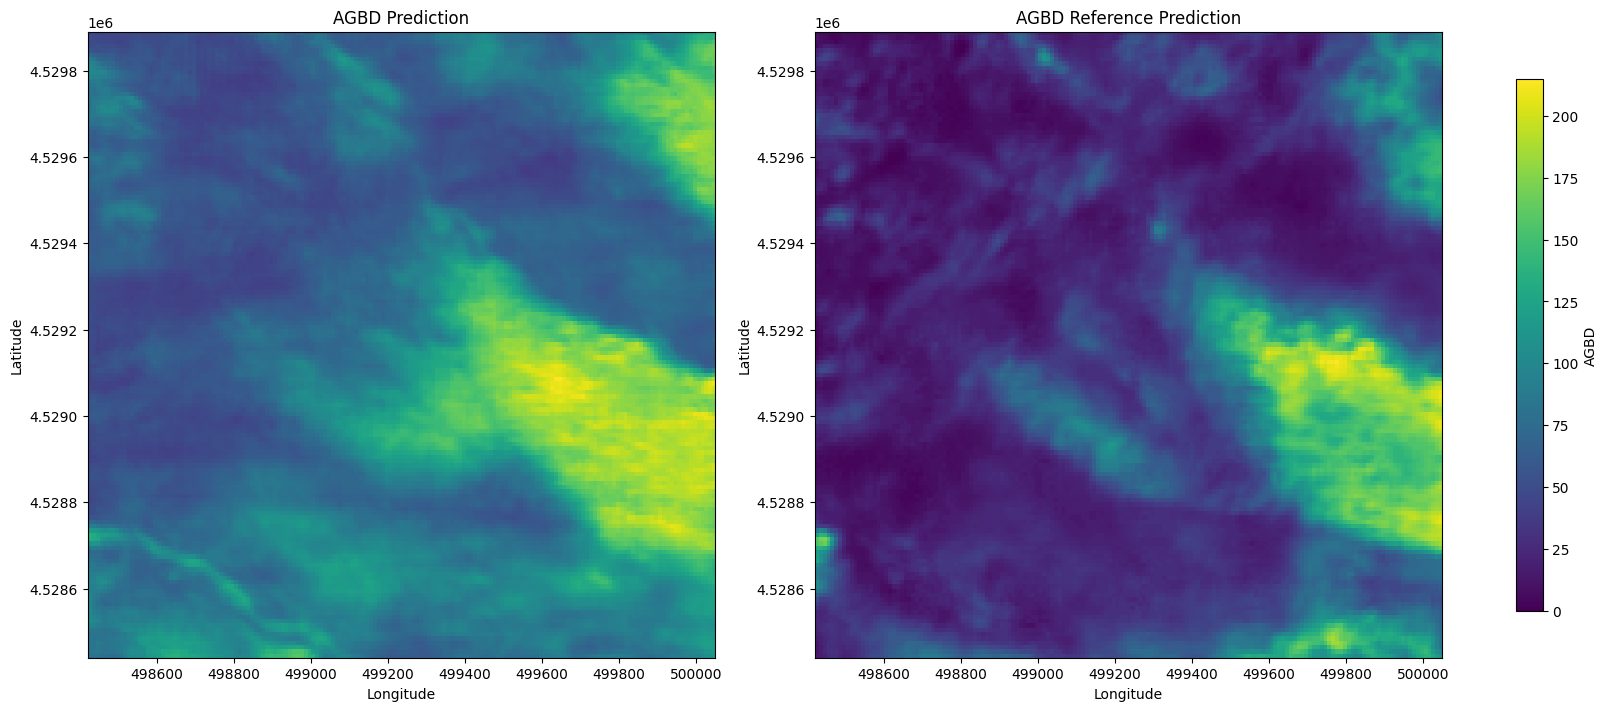

In [ ]:
# ---------------------------------------------------------------------------#
# Comparison between prediction and reference
# ---------------------------------------------------------------------------#
# reference was downloaded from https://libdrive.ethz.ch/index.php/s/VPio6i5UlXTgir0/download?path=%2Fpredictions&files=34TGL.tif
# at the beginning of the notebook

AGBD = rxr.open_rasterio("AGB_Notebook_Prediction.tif", masked=True).squeeze()
AGBD_REF = rxr.open_rasterio("AGB_Authors_Reference.tif", masked=True).squeeze()

agbd_vals = AGBD.values
ref_vals = AGBD_REF.values

all_vals = np.concatenate([
    agbd_vals[np.isfinite(agbd_vals)],
    ref_vals[np.isfinite(ref_vals)]
])

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# Left panel
im0 = AGBD.plot.imshow(
    ax=axes[0],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
axes[0].set_title("AGBD Prediction")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Right panel
im1 = AGBD_REF.plot.imshow(
    ax=axes[1],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
axes[1].set_title("AGBD Reference Prediction")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# One shared colorbar
cbar = fig.colorbar(im1, ax=axes, shrink=0.85)
cbar.set_label("AGBD")

plt.show()